In [36]:
import os
import datetime

import torch
import torch.utils.data
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from torch import nn, optim
from torch.nn import functional as F
from torchvision.utils import save_image

In [37]:
RESULTS_PATH = "./results"
hyperparameters = {
    "lr": 1e-3,
    "batch_size": 64,
    "num_epochs": 1000,
    "log_interval": 100,
    "latent_dim": 20,
    "device": 'cuda' if torch.cuda.is_available() else 'cpu'
}

In [38]:
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=True, download=True, transform=transforms.ToTensor()),
    batch_size=hyperparameters['batch_size'], shuffle=True)
test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=False, transform=transforms.ToTensor()),
    batch_size=hyperparameters['batch_size'], shuffle=False)

# Data Exploration

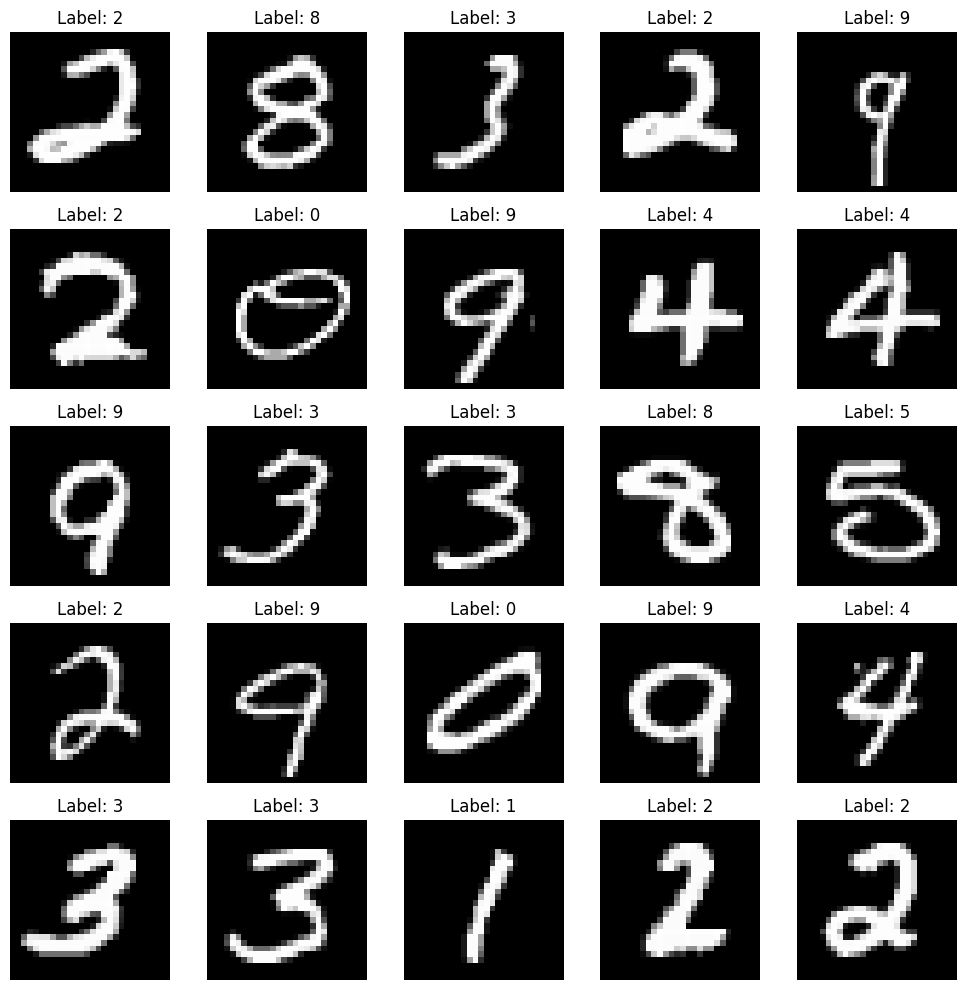

In [39]:
# Get a batch of images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Create a 5x5 grid
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
axes = axes.ravel()

# Plot 25 images
for idx in range(25):
    axes[idx].imshow(images[idx].squeeze(), cmap='gray')
    axes[idx].set_title(f'Label: {labels[idx]}')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Model

In [57]:
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        self.fc1 = nn.Linear(784, 400)
        self.fc21 = nn.Linear(400, hyperparameters['latent_dim'])
        self.fc22 = nn.Linear(400, hyperparameters['latent_dim'])
        self.fc3 = nn.Linear(hyperparameters['latent_dim'], 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        h1 = F.relu(self.fc1(x.view(-1, 784)))
        return self.fc21(h1), self.fc22(h1) # return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x) # shape: [batch_size, 784]
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [58]:
model = VAE().to(hyperparameters['device'])
optimizer = optim.Adam(model.parameters(), lr=hyperparameters['lr'])

# Training functions

In [51]:
# Reconstruction + KL divergence losses summed over all elements and batch
def loss_function(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')

    # see Appendix B from VAE paper:
    # Kingma and Welling. Auto-Encoding Variational Bayes. ICLR, 2014
    # https://arxiv.org/abs/1312.6114
    # 0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE + KLD

def train(epoch):
    model.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(hyperparameters['device'])
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        if batch_idx % hyperparameters['log_interval'] == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader),
                loss.item() / len(data)))

    print('====> Epoch: {} Average loss: {:.4f}'.format(
          epoch, train_loss / len(train_loader.dataset)))


def test(epoch, result_save_path):
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for i, (data, _) in enumerate(test_loader):
            data = data.to(hyperparameters['device'])
            recon_batch, mu, logvar = model(data)
            test_loss += loss_function(recon_batch, data, mu, logvar).item()
            if i == 0:
                n = min(data.size(0), 8)
                comparison = torch.cat([data[:n], recon_batch.view(hyperparameters['batch_size'], 1, 28, 28)[:n]])
                save_image(comparison.cpu(), os.path.join(result_save_path, f"reconstruction_{str(epoch)}.png"), nrow=n)

    test_loss /= len(test_loader.dataset)
    print('====> Test set loss: {:.4f}'.format(test_loss))

# Training

In [59]:
result_save_path = os.path.join(RESULTS_PATH, str(datetime.datetime.now()))
if not os.path.exists(result_save_path):
    os.makedirs(result_save_path)

for epoch in range(1, hyperparameters['num_epochs'] + 1):
        train(epoch)
        test(epoch, result_save_path)
        with torch.no_grad():
            sample = torch.randn(64, hyperparameters['latent_dim']).to(hyperparameters['device'])
            sample = model.decode(sample).cpu()
            save_image(sample.view(64, 1, 28, 28), os.path.join(result_save_path, f"sample_{str(epoch)}.png"))

Train Epoch: 1 [0/60000 (0%)]	Loss: 549.806824
Train Epoch: 1 [6400/60000 (11%)]	Loss: 183.478546
Train Epoch: 1 [12800/60000 (21%)]	Loss: 153.463760
Train Epoch: 1 [19200/60000 (32%)]	Loss: 145.816101
Train Epoch: 1 [25600/60000 (43%)]	Loss: 138.340256
Train Epoch: 1 [32000/60000 (53%)]	Loss: 128.141800
Train Epoch: 1 [38400/60000 (64%)]	Loss: 123.764999
Train Epoch: 1 [44800/60000 (75%)]	Loss: 118.291664
Train Epoch: 1 [51200/60000 (85%)]	Loss: 127.038994
Train Epoch: 1 [57600/60000 (96%)]	Loss: 114.145454
====> Epoch: 1 Average loss: 146.8864
====> Test set loss: 119.2127


KeyboardInterrupt: 

# Visualization

In [ ]:
with torch.no_grad():
    for i, (data, _) in enumerate(test_loader):
        data = data.to(hyperparameters['device'])
        mu, logvar = model.encode(data)
        